# READ BEFORE CONTINUE

- Untuk mendapatkan akses edit kalian bisa membuat copy di perangkat kalian masing-masing dengan menggunakan akun gmail masing-masing (Menu File -> Save copy in Drive)

# MODUL 4 - Regression and Classification in Different Dataset Types


Disusun oleh:
1. Alviya Laela Lestari
2. Kiara Azzahra

Diaudit oleh:
Yufis Azhar, S.Kom, M.Kom

Presented by: TIM LAB-IT Universitas Muhammadiyah Malang

## Persiapan Software/Apilkasi

**1. Hardware**
- Laptop/Komputer

**2. Software (Pilih salah satu)**
- Visual Studio Code, Google Collaboratory, PyCharm, Jupyter Notebook


## Klasifikasi dan Regresi


**Klasifikasi (classification)** sering digunakan dalam menganalisis data untuk mengelompokkan data ke dalam kategori tertentu berdasarkan karakteristik atau fitur yang dimiliki oleh sebuah data. Misalnya, sebuah bank dapat memutuskan apakah akan memberikan pinjaman kepada nasabah berdasarkan riwayat kreditnya.

Sedangkan **regresi (regression)** sering digunakan untuk memprediksi nilai atau mengestimasi tren. Model regresi mencoba memahami hubungan antara variabel independen (fitur) dan variabel dependen (target) agar bisa membuat prediksi berdasarkan data baru. Contohnya, memprediksi harga rumah dengan menentukan fitur seperti luas rumah, jumlah kamar, dan lokasi.

# Strutured Data

Dataset yang memiliki struktur yang terorganisir dan format yang jelas disebut dengan **dataset terstruktur (structured dataset)**. Dataset yang terstrukur seringkali ditampilkan dalam bentuk tabel dengan baris dan kolom yang terdefinisi. Setiap baris merepresentasikan satu entitas atau observasi, sementara setiap kolom menunjukkan atribut atau karakteristik yang dimiliki oleh entitas tersebut.


## Klasifikasi Data Tabular

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### Persiapan Data

[Sumber Dataset Bank Marketing](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing)

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [ ]:
#!/bin/bash
!kaggle datasets download henriqueyamahata/bank-marketing

Dataset URL: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing
License(s): other


In [ ]:
!unzip /content/bank-marketing.zip

Archive:  /content/bank-marketing.zip
  inflating: bank-additional-full.csv  
  inflating: bank-additional-names.txt  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.duplicated().sum()

np.int64(12)

### Feature Selection


In [ ]:
selected_features = ['age', 'job', 'marital', 'default', 'loan', 'housing',
                     'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
target = 'y'
filtered_data = df[selected_features + [target]]

### Text-to-Numeric

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for column in filtered_data.select_dtypes(include=['object']).columns:
    if column != target:  # Exclude the target column for now
        label_encoders[column] = LabelEncoder()
        filtered_data[column] = label_encoders[column].fit_transform(filtered_data[column])

In [ ]:
target_encoder = LabelEncoder()
filtered_data[target] = target_encoder.fit_transform(filtered_data[target])

### Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split
X = filtered_data[selected_features]
y = filtered_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print("\nData Split:")
print(f"Training Features: {X_train.shape}, Training Labels: {y_train.shape}")
print(f"Testing Features: {X_test.shape}, Testing Labels: {y_test.shape}")



Data Split:
Training Features: (32950, 11), Training Labels: (32950,)
Testing Features: (8238, 11), Testing Labels: (8238,)


### Modelling


In [ ]:
# Import library model
from sklearn.ensemble import RandomForestClassifier #Random Forest
from sklearn.naive_bayes import GaussianNB # Naive Bayes
from sklearn.tree import DecisionTreeClassifier # Decision Tree
from sklearn.neighbors import KNeighborsClassifier # KNN
from sklearn.svm import SVC # SVM

In [ ]:
# Karena disini kita akan mencoba beberapa model,
# Beberapa model akan dijadikan dalam satu variabel

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=3),
    "Support Vector Machine": SVC(random_state=42)
}

### Evaluasi Model

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
# Evaluasi
scores = []

for model_name, model in models.items():
    print(f"=== {model_name} ===")

    # Fitting model
    model.fit(X_train, y_train)

    # Prediksi data uji
    y_pred = model.predict(X_test)

    # Hitung akurasi
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)  # Simpan akurasi ke dalam list

    # Tampilkan hasil evaluasi
    print("Accuracy:", acc)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

=== Random Forest ===
Accuracy: 0.8738771546491867
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7303
           1       0.41      0.27      0.33       935

    accuracy                           0.87      8238
   macro avg       0.66      0.61      0.63      8238
weighted avg       0.85      0.87      0.86      8238



=== Naive Bayes ===
Accuracy: 0.7453265355668852
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      7303
           1       0.26      0.69      0.38       935

    accuracy                           0.75      8238
   macro avg       0.61      0.72      0.61      8238
weighted avg       0.87      0.75      0.79      8238



=== Decision Tree ===
Accuracy: 0.8443797038116048
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      7303
           1 

In [ ]:
# Mengurutkan model berdasarkan akurasi tertinggi
results = pd.DataFrame({
    'Models': list(models.keys()),
    'Accuracy': scores
})

sorted_results = results.sort_values(by='Accuracy', ascending=False)
print(sorted_results)

                   Models  Accuracy
4  Support Vector Machine  0.886502
0           Random Forest  0.873877
3     K-Nearest Neighbors  0.873027
2           Decision Tree  0.844380
1             Naive Bayes  0.745327


## Regresi Data Tabular



### Persiapan Data

[Sumber Dataset Advertising](https://www.kaggle.com/datasets/ashydv/advertising-dataset)

In [ ]:
#!/bin/bash
!kaggle datasets download ashydv/advertising-dataset
!unzip advertising-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/ashydv/advertising-dataset
License(s): unknown
  0% 0.00/1.83k [00:00<?, ?B/s]
100% 1.83k/1.83k [00:00<00:00, 4.86MB/s]
Archive:  advertising-dataset.zip
  inflating: advertising.csv         


In [ ]:
df_advertising = pd.read_csv('advertising.csv')
df_advertising.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


### Data Cleaning

In [ ]:
df_advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df_advertising.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
df_advertising.duplicated().sum()

0

Karena dataset kita sudah berisi numerik, jadi tidak perlu mengubahnya lagi.

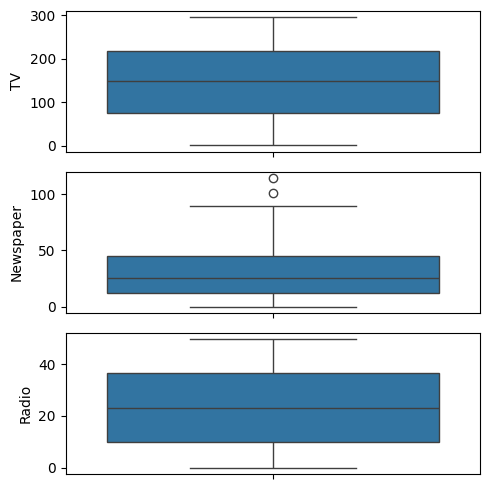

In [ ]:
# Outlier Analysis
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(3, figsize = (5,5))
plt1 = sns.boxplot(df_advertising['TV'], ax = axs[0])
plt2 = sns.boxplot(df_advertising['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(df_advertising['Radio'], ax = axs[2])
plt.tight_layout()

Tidak ada outliers yang cukup besar pada data jadi sudah aman untuk diolah

### Splitting Data

In [ ]:
X_tabular_reg = df_advertising[['TV', 'Newspaper', 'Radio']]
y_tabular_reg = df_advertising['Sales']

In [ ]:
X_train_tabular_reg, X_test_tabular_reg, y_train_tabular_reg, y_test_tabular_reg = train_test_split(X_tabular_reg, y_tabular_reg, train_size = 0.7, test_size = 0.3, random_state = 100)

In [ ]:
X_train_tabular_reg.shape

(140, 3)

In [ ]:
y_train_tabular_reg.shape

(140,)

### Modelling

In [ ]:
# Import library
from sklearn.linear_model import LinearRegression     # Regresi Linear
from sklearn.linear_model import Ridge, Lasso         # Regresi Ridge dan Lasso
from sklearn.preprocessing import PolynomialFeatures  # Regresi Polynomial
from sklearn.linear_model import LogisticRegression   # Logistic Regression

In [ ]:
model_regresi_tabular = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),  # Alpha adalah parameter regulasi
    'Lasso Regression': Lasso(alpha=0.1),
}

# Membuat fitur polinomial untuk Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)  # Transformasi fitur

# Tambahkan model Polynomial Regression
model_regresi_tabular['Polynomial Regression'] = LinearRegression()

In [ ]:
# Melatih setiap model
for model_name, model in model_regresi_tabular.items():
    if model_name == 'Polynomial Regression':
        model.fit(X_poly, y)
    else:
        model.fit(X, y)
    print(f"{model_name} successfuly trained")

Linear Regression successfuly trained
Ridge Regression successfuly trained
Lasso Regression successfuly trained
Polynomial Regression successfuly trained


### Evaluasi Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

score_tabular_reg = []
for model_name, model in model_regresi_tabular.items():
    # Training model
    model.fit(X_train_tabular_reg, y_train_tabular_reg)
    y_pred_tabular_reg = model.predict(X_test_tabular_reg)

    # Calculate regression metrics (e.g., MSE and R-squared)
    mse = mean_squared_error(y_test_tabular_reg, y_pred_tabular_reg)
    mae = mean_absolute_error(y_test_tabular_reg, y_pred_tabular_reg)
    r2 = r2_score(y_test_tabular_reg, y_pred_tabular_reg)
    score_tabular_reg.append([model_name, mae, mse, r2])

In [ ]:
results_df_tabular_reg = pd.DataFrame(score_tabular_reg, columns=['Model', 'MSE', 'MAE', 'R-squared'])
print(results_df_tabular_reg)

                   Model       MSE       MAE  R-squared
0      Linear Regression  1.227818  2.636077   0.865598
1       Ridge Regression  1.227819  2.636066   0.865598
2       Lasso Regression  1.226969  2.631160   0.865849
3  Polynomial Regression  1.227818  2.636077   0.865598


## Regresi Time Series

Regresi adalah tugas menetapkan output bernilai nyata ke contoh input. Misalnya, kita ingin memprediksi harga jual, merupakan sebuah bilangan real, dari sebuah rumah dengan mempertimbangkan lokasi, luas, ukuran kavling, jumlah kamar tidur, kamar mandi, dan fasilitas terpasang. Di bawah ini, beberapa metode pendekatan paling populer untuk regresi.
* Linear regression
* Bayesian linear regression
* Random forest regression
* Nearest neighbors regression



### Persiapan Data

[Sumber dataset](https://www.kaggle.com/datasets/arashnic/time-series-forecasting-with-yahoo-stock-price)

In [ ]:
!kaggle datasets download -d arashnic/time-series-forecasting-with-yahoo-stock-price

Dataset URL: https://www.kaggle.com/datasets/arashnic/time-series-forecasting-with-yahoo-stock-price
License(s): CC0-1.0
  0% 0.00/33.1k [00:00<?, ?B/s]
100% 33.1k/33.1k [00:00<00:00, 43.8MB/s]


In [ ]:
!unzip -q 'time-series-forecasting-with-yahoo-stock-price.zip'

In [ ]:
!ls

advertising.csv		   bank-marketing.zip
advertising-dataset.zip    sample_data
bank-additional-full.csv   time-series-forecasting-with-yahoo-stock-price.zip
bank-additional-names.txt  yahoo_stock.csv


In [ ]:
import pandas as pd

df_yahoo = pd.read_csv("yahoo_stock.csv")
df_yahoo.head(5)

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


### Data Preprocessing

In [ ]:
# konversi kolom 'Date' menjadi format Datetime
df_yahoo['Date']= pd.to_datetime(df_yahoo['Date'])

df_yahoo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1825 non-null   datetime64[ns]
 1   High       1825 non-null   float64       
 2   Low        1825 non-null   float64       
 3   Open       1825 non-null   float64       
 4   Close      1825 non-null   float64       
 5   Volume     1825 non-null   float64       
 6   Adj Close  1825 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 99.9 KB


In [ ]:
df_yahoo.isnull().sum()

,0
Date,0
High,0
Low,0
Open,0
Close,0
Volume,0
Adj Close,0


### Visualisasi

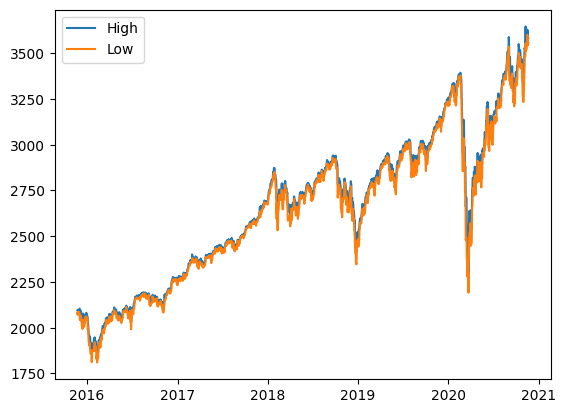

In [ ]:
import matplotlib.pyplot as plt

# plt.figure(figsize =(14, 8))
plt.plot(df_yahoo.Date, df_yahoo.High, label = "High")
plt.plot(df_yahoo.Date, df_yahoo.Low, label = "Low")
plt.legend()
plt.show()

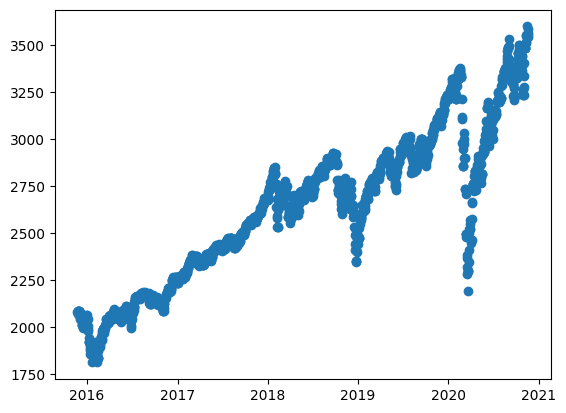

In [ ]:
plt.scatter(x = df_yahoo['Date'], y = df_yahoo['Low'])

Untuk percobaan regresi pada data timeseries pada modul ini kita hanya menggunakan fitur 'Low' sebagai variabel dependen (Y) dan fitur 'Date' sebagai variabel independen(X).

### Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split


X= df_yahoo[["Date"]]
y= df_yahoo[["Low"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train, np.ravel(y_train))


RandomForestRegressor()

### Evaluasi Model RFR

Disini kita akan membandingkan nilai aktual dan nilai prediksi untuk menghitung akurasi model regresi. Metrik evaluasi memberikan peran kunci dalam pengembangan model, karena memberikan wawasan tentang bidang-bidang yang membutuhkan perbaikan.

Ada metrik evaluasi model yang berbeda, mari gunakan MSE di sini untuk menghitung akurasi model kita berdasarkan pada set tes:

* Mean absolute error: Ini adalah rata-rata dari nilai absolut kesalahan. Ini adalah metrik termudah untuk dipahami karena itu hanya kesalahan rata-rata.

* Mean Squared Error (MSE): Mean Squared Error (MSE) adalah rata-rata dari kesalahan kuadrat. Ini lebih populer daripada kesalahan absolut rata-rata karena fokus lebih diarahkan pada kesalahan besar. Ini karena istilah kuadrat secara eksponensial meningkatkan kesalahan yang lebih besar dibandingkan dengan yang lebih kecil.

* Root Mean Squared Error (RMSE) : RMSE dihitung dengan mengkuadratkan error (prediksi – observasi) dibagi dengan jumlah data (= rata-rata), lalu diakarkan..

* R-squared bukan kesalahan, tetapi merupakan metrik populer untuk akurasi model. Ini menunjukkan seberapa dekat data dengan garis regresi yang sesuai. Semakin tinggi R-squared, semakin baik model sesuai dengan data. Skor terbaik yang mungkin adalah 1.0 dan bisa negatif (karena modelnya bisa lebih buruk secara sewenang-wenang).

*ingat pelajaran statistik dan metode numerik di semester sebelumnya*

In [ ]:
from sklearn.metrics import r2_score

y_pred = rf_regressor.predict(X_test)
y_pred_train = rf_regressor.predict(X_train)


print(f"Evaluasi R-Square Data Train {r2_score(y_train, y_pred_train)}")
print(f"Evaluasi R-Square Data Test {r2_score(y_test, y_pred)}")

Evaluasi R-Square Data Train 0.9996183437044724
Evaluasi R-Square Data Test 0.9978053539327089


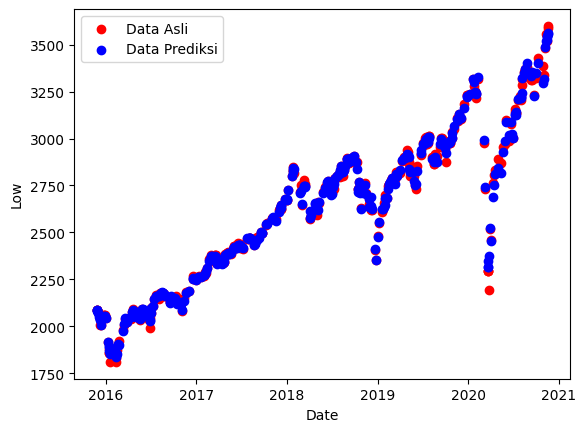

In [ ]:
# plot perbandingan data sebenarnya data dan data prediksi
fig, ax = plt.subplots()
plt.xlabel("Date")
plt.ylabel("Low")

ax.scatter(X_test,y_test, color = "red", label = "Data Asli")
ax.scatter(X_test,y_pred, color = "blue", label = "Data Prediksi")
plt.legend()
plt.show()




# Unstructured Data

## Klasifikasi Data Teks

### Persiapan Data
[Sumber Dataset SMS](https://www.kaggle.com/datasets/mariumfaheem666/spam-sms-classification-using-nlp)

In [ ]:
#!/bin/bash
!kaggle datasets download mariumfaheem666/spam-sms-classification-using-nlp

Dataset URL: https://www.kaggle.com/datasets/mariumfaheem666/spam-sms-classification-using-nlp
License(s): apache-2.0
  0% 0.00/209k [00:00<?, ?B/s]
100% 209k/209k [00:00<00:00, 82.7MB/s]


In [ ]:
!unzip spam-sms-classification-using-nlp.zip

Archive:  spam-sms-classification-using-nlp.zip
  inflating: Spam_SMS.csv            


In [ ]:
df_sms = pd.read_csv('Spam_SMS.csv')
df_sms.head(5)

,Class,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df_sms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Class    5574 non-null   object
 1   Message  5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### Data Cleaning

In [ ]:
import re

df_sms['Message'] = df_sms['Message'].str.lower()
df_sms['Message'] = df_sms['Message'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

In [ ]:
df_sms

,Class,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...
...,...,...
5569,spam,this is the 2nd time we have tried 2 contact u...
5570,ham,will b going to esplanade fr home
5571,ham,pity was in mood for that soany other suggest...
5572,ham,the guy did some bitching but i acted like id ...


Untuk menggunakan data ini dalam Machine Learning, kita harus mengubah konten setiap string atau teks menjadi vektor angka. Untuk itu kita akan menggunakan vectorizer TF-IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create feature vectors
vectorizer = TfidfVectorizer()
X_sms = vectorizer.fit_transform(df_sms['Message']).toarray()
y_sms = df_sms["Class"]

In [ ]:
X_sms.shape

(5574, 9541)

### Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(X_sms,y_sms,test_size=0.3,random_state=0)
X_train_sms.shape , y_test_sms.shape

((3901, 9541), (1673,))

### Model Naive Bayes

Mari kita coba untuk membandingkan model Naive Bayes dan ANN

In [ ]:
# Import Library
from sklearn.naive_bayes import MultinomialNB # Menggunakan tipe multinomial
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# Model Naive Bayes
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train_sms, y_train_sms)
y_pred = nb_model.predict(X_test_sms)

### Model ANN

Untuk model Neural Network, kita dapat menyusun lapisan (layer) sesuai dengan kebutuhan dataset dan masalah yang ingin diselesaikan. Selain menyusun layer secara manual, kita juga bisa memanfaatkan model deep learning yang sudah dilatih sebelumnya (pretrained model) untuk tugas tertentu, terutama jika dataset yang dimiliki terbatas. Namun, semakin kompleks arsitektur model atau jumlah layer yang digunakan, semakin besar kebutuhan dataset dan kekuatan komputasi untuk melatih model tersebut.

Sebelum kita membuat modelnya, model ANN membutuhkan input numerik untuk data olah, maka kita akan menggunakan encoder untuk mengubahnya ke dalam bentuk numerik

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_sms_ann = label_encoder.fit_transform(y_train_sms)  # Convert y_train ke bentuk numerik
y_test_sms_ann = label_encoder.transform(y_test_sms)  # Convert y_test_sms ke bentuk numerik

In [ ]:
# Model ANN

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sms.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
ann_hist = ann_model.fit(X_train_sms, y_train_sms_ann, epochs=10, batch_size=32, validation_split=0.3, validation_data=(X_test_sms, y_test_sms_ann))

Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8265 - loss: 0.5498 - val_accuracy: 0.8565 - val_loss: 0.2373
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9125 - loss: 0.1851 - val_accuracy: 0.9737 - val_loss: 0.1025
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9877 - loss: 0.0559 - val_accuracy: 0.9803 - val_loss: 0.0704
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9930 - loss: 0.0282 - val_accuracy: 0.9791 - val_loss: 0.0722
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9973 - loss: 0.0158 - val_accuracy: 0.9797 - val_loss: 0.0748
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9982 - loss: 0.0111 - val_accuracy: 0.9803 - val_loss: 0.0791
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9980 - loss: 0.0066 - val_accuracy: 0.9779 - val_loss: 0.0872
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9989 - loss: 0.0061 - val_accu

In [ ]:
y_pred_ann = (ann_model.predict(X_test_sms) > 0.5).astype(int)
ann_accuracy = accuracy_score(y_test_sms_ann.astype(int), y_pred_ann)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
model_text = pd.DataFrame({
    'Models': ['Naive Bayes', 'ANN'],
    'Accuracy': [accuracy_score(y_test_sms, y_pred), ann_accuracy]
})

print(model_text)

        Models  Accuracy
0  Naive Bayes  0.942618
1          ANN  0.979677


In [ ]:
# Prediksi Naive Bayes dengan teks diluar dataset

new_string = "wish you all the best"
s = [new_string]
new_X_test = vectorizer.transform(s).toarray()
pred = nb_model.predict(new_X_test)
print(f"kalimat ({new_string}), bermuatan {pred[0]}")

kalimat (wish you all the best), bermuatan ham


## Klasifikasi Data Citra

Saranku, untuk code dibawah ini jangan dirun ulang yaa karena membutuhkan waktu lama untuk training modelnya. Tapi, kalau mau modifikasi dan sebagainya, silahkannn :D

### Persiapan Data

[Dataset Alpaca](https://www.kaggle.com/datasets/sid4sal/alpaca-dataset-small)

In [ ]:
#!/bin/bash
!kaggle datasets download sid4sal/alpaca-dataset-small

Dataset URL: https://www.kaggle.com/datasets/sid4sal/alpaca-dataset-small
License(s): CC0-1.0
 97% 113M/116M [00:01<00:00, 115MB/s]
100% 116M/116M [00:01<00:00, 100MB/s]


In [ ]:
!unzip alpaca-dataset-small.zip

Archive:  alpaca-dataset-small.zip
  inflating: dataset/alpaca/01ad3ff1d94eb557.jpg  
  inflating: dataset/alpaca/0346463867a297f4.jpg  
  inflating: dataset/alpaca/038fae9e70c4c3f1.jpg  
  inflating: dataset/alpaca/053608552d63f724.jpg  
  inflating: dataset/alpaca/053dab62fbb47736.jpg  
  inflating: dataset/alpaca/063a50c0a6408396.jpg  
  inflating: dataset/alpaca/098cc30753a9cf13.jpg  
  inflating: dataset/alpaca/09915aad4cd6bf0d.jpg  
  inflating: dataset/alpaca/09e382a83978039b.jpg  
  inflating: dataset/alpaca/0a2ea8f93b4cb30a.jpg  
  inflating: dataset/alpaca/0b2a2c061ef16759.jpg  
  inflating: dataset/alpaca/0cb5cae66bb9c4cd.jpg  
  inflating: dataset/alpaca/0dba33ff827acee8.jpg  
  inflating: dataset/alpaca/0e6044cdcd9318f3.jpg  
  inflating: dataset/alpaca/0e6ba4d54d478f76.jpg  
  inflating: dataset/alpaca/10371d58e9cf119d.jpg  
  inflating: dataset/alpaca/1076411586a28251.jpg  
  inflating: dataset/alpaca/122dea74b00f325e.jpg  
  inflating: dataset/alpaca/1242ba953cd74e4b.jp

In [ ]:
import os
import PIL as Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix ,classification_report

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adamax
from keras.layers import Dense,Conv2D,MaxPooling2D,Dropout,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_data_dir='/content/dataset'
filepaths=[]
labels=[]
folds=os.listdir(train_data_dir)
for fold in folds:
    fpath=os.path.join(train_data_dir,fold)
    fpaths=os.listdir(fpath)
    for i in fpaths:
        fi_path=os.path.join(fpath,i)
        filepaths.append(fi_path)
        labels.append(fold)
fseries=pd.Series(filepaths,name='filepaths')
lseries=pd.Series(labels,name='labels')
df=pd.concat([fseries,lseries],axis=1)
df

,filepaths,labels
0,/content/dataset/alpaca/83b4c57707e97640.jpg,alpaca
1,/content/dataset/alpaca/69b3d46933afff69.jpg,alpaca
2,/content/dataset/alpaca/d0b4c8cd3cb8be00.jpg,alpaca
3,/content/dataset/alpaca/9eed92c49db828f1.jpg,alpaca
4,/content/dataset/alpaca/8bf4896f078db938.jpg,alpaca
...,...,...
322,/content/dataset/not alpaca/cd2936244741d3e0.jpg,not alpaca
323,/content/dataset/not alpaca/17c823ab5eeb6a69.jpg,not alpaca
324,/content/dataset/not alpaca/77d8f1427530d52c.jpg,not alpaca
325,/content/dataset/not alpaca/039dfd67a8e053b8.jpg,not alpaca


### Visualization

In [ ]:
count =df['labels'].value_counts()
count

,count
labels,
not alpaca,185
alpaca,142


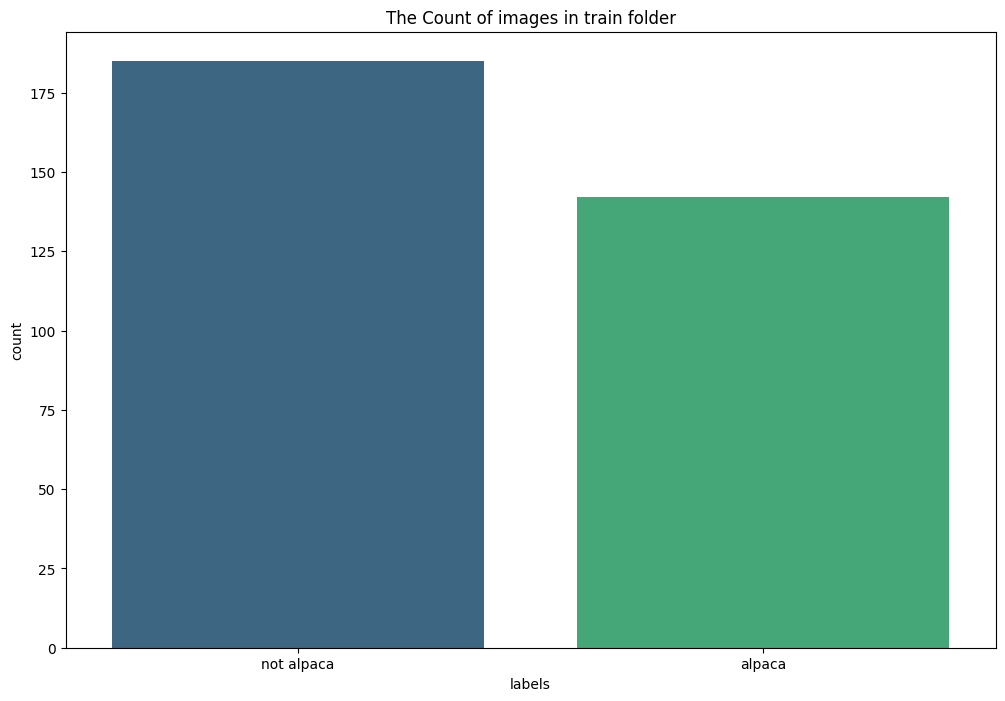

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(x=count.index,y=count.values,palette='viridis')
plt.title('The Count of images in train folder')
plt.xlabel('labels')
plt.ylabel('count')
plt.show()

### Splitting Data

In [ ]:
train_df , dummy_df=train_test_split(df,test_size=0.2,shuffle=True,random_state=42)
valid_df,test_df=train_test_split(df,test_size=0.4,shuffle=True,random_state=42)

In [ ]:
train_df

,filepaths,labels
183,/content/dataset/not alpaca/7355d53dfbb9124c.jpg,not alpaca
17,/content/dataset/alpaca/475481b3737b7d38.jpg,alpaca
24,/content/dataset/alpaca/8b2acfbdda201cc5.jpg,alpaca
132,/content/dataset/alpaca/4684e1fba3516b80.jpg,alpaca
113,/content/dataset/alpaca/0b2a2c061ef16759.jpg,alpaca
...,...,...
188,/content/dataset/not alpaca/8f7e6728e105904a.jpg,not alpaca
71,/content/dataset/alpaca/01ad3ff1d94eb557.jpg,alpaca
106,/content/dataset/alpaca/16e2d08c3fe1963c.jpg,alpaca
270,/content/dataset/not alpaca/48f7992c2ca04cde.jpg,not alpaca


In [ ]:
test_df

,filepaths,labels
231,/content/dataset/not alpaca/2cb74ee0c15aa4fd.jpg,not alpaca
110,/content/dataset/alpaca/e89e4b8eaf43e06a.jpg,alpaca
250,/content/dataset/not alpaca/02f783a758aec795.jpg,not alpaca
9,/content/dataset/alpaca/6216ff170d2c2b35.jpg,alpaca
93,/content/dataset/alpaca/7a613b27fa7851ce.jpg,alpaca
...,...,...
185,/content/dataset/not alpaca/9abdf147aa9949fe.jpg,not alpaca
69,/content/dataset/alpaca/532b0e58c0d5dbcd.jpg,alpaca
97,/content/dataset/alpaca/2c6af9b53f4cb15a.jpg,alpaca
165,/content/dataset/not alpaca/8b5c3f36d11757d6.jpg,not alpaca


In [ ]:
valid_df

,filepaths,labels
23,/content/dataset/alpaca/da53a365b9dc1714.jpg,alpaca
37,/content/dataset/alpaca/45e4604794830664.jpg,alpaca
237,/content/dataset/not alpaca/0155b267ade95d1e.jpg,not alpaca
67,/content/dataset/alpaca/e9a2edc24c4ae2fb.jpg,alpaca
262,/content/dataset/not alpaca/bfdc9ae0023e63ca.jpg,not alpaca
...,...,...
188,/content/dataset/not alpaca/8f7e6728e105904a.jpg,not alpaca
71,/content/dataset/alpaca/01ad3ff1d94eb557.jpg,alpaca
106,/content/dataset/alpaca/16e2d08c3fe1963c.jpg,alpaca
270,/content/dataset/not alpaca/48f7992c2ca04cde.jpg,not alpaca


In [ ]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 261 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.
Found 131 validated image filenames belonging to 2 classes.


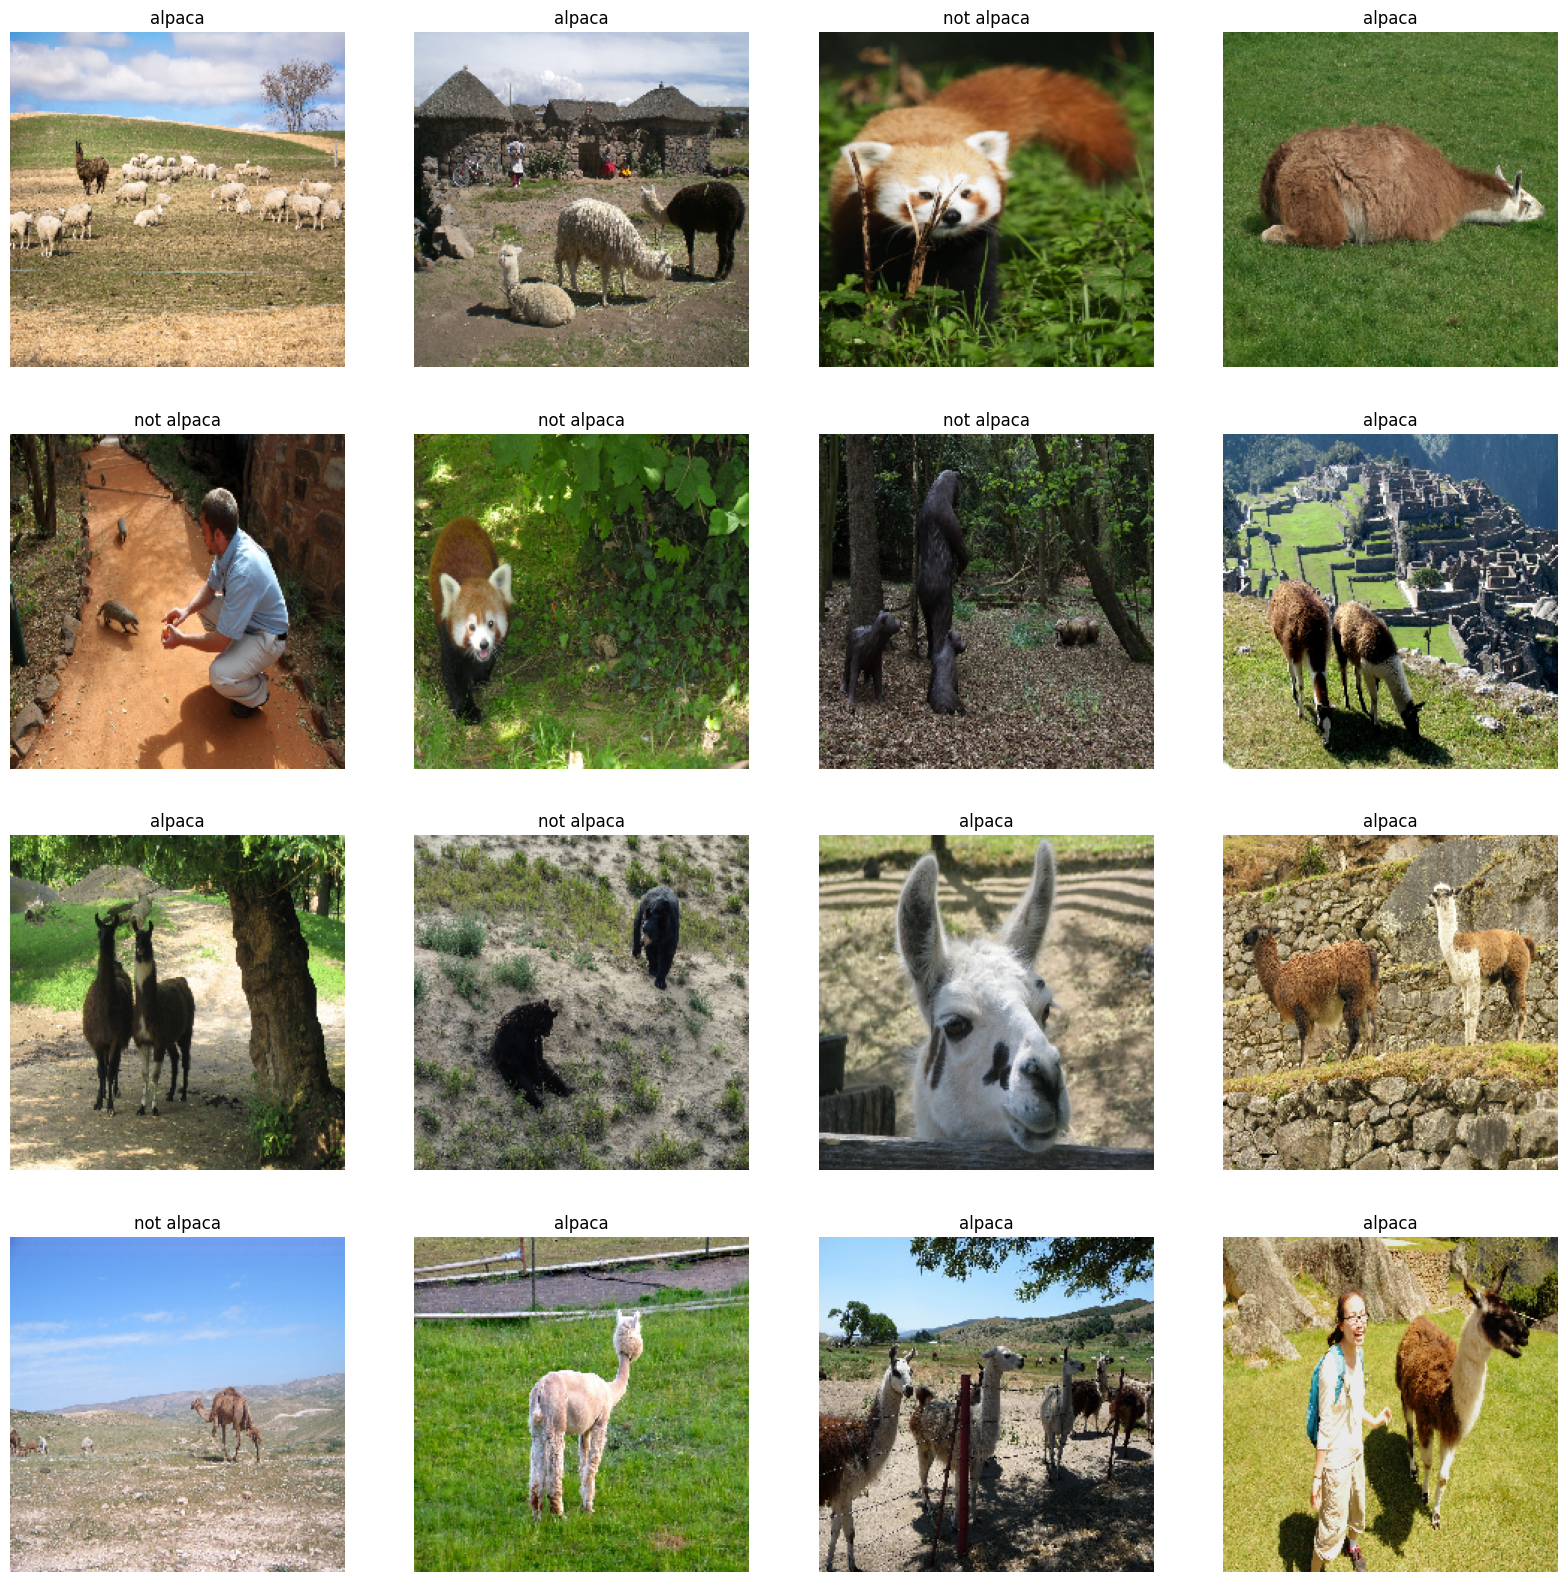

In [ ]:
g_dict = train_gen.class_indices
classes = list(g_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color= 'black', fontsize= 12)
    plt.axis('off')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=img_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Add dropout for regularization
    Dense(len(classes), activation='softmax')  # Output layer with softmax
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)


history = model.fit(
    train_gen,
    epochs=50,  # Increased epochs for better convergence potential
    validation_data=valid_gen,
    callbacks=[early_stopping] # Added early stopping
)


# Evaluate the model
loss, accuracy = model.evaluate(test_gen)
print(f"Test Accuracy: {accuracy}")

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.4467 - loss: 195.9638 - val_accuracy: 0.7296 - val_loss: 0.5533
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.6895 - loss: 0.5589 - val_accuracy: 0.7653 - val_loss: 0.4589
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.7231 - loss: 0.5247 - val_accuracy: 0.8827 - val_loss: 0.3256
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8465 - loss: 0.3628 - val_accuracy: 0.9184 - val_loss: 0.2229
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8765 - loss: 0.2987 - val_accuracy: 0.9694 - val_loss: 0.0959
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9066 - loss: 0.1696 - val_accuracy: 0.9541 - val_loss: 0.0839
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9645 - loss: 0.1237 - val_accuracy: 0.9643 - val_loss: 0.0530
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9602 - loss: 0.0755 - val_accuracy: 0.9643 - val_los

### Evaluasi Model

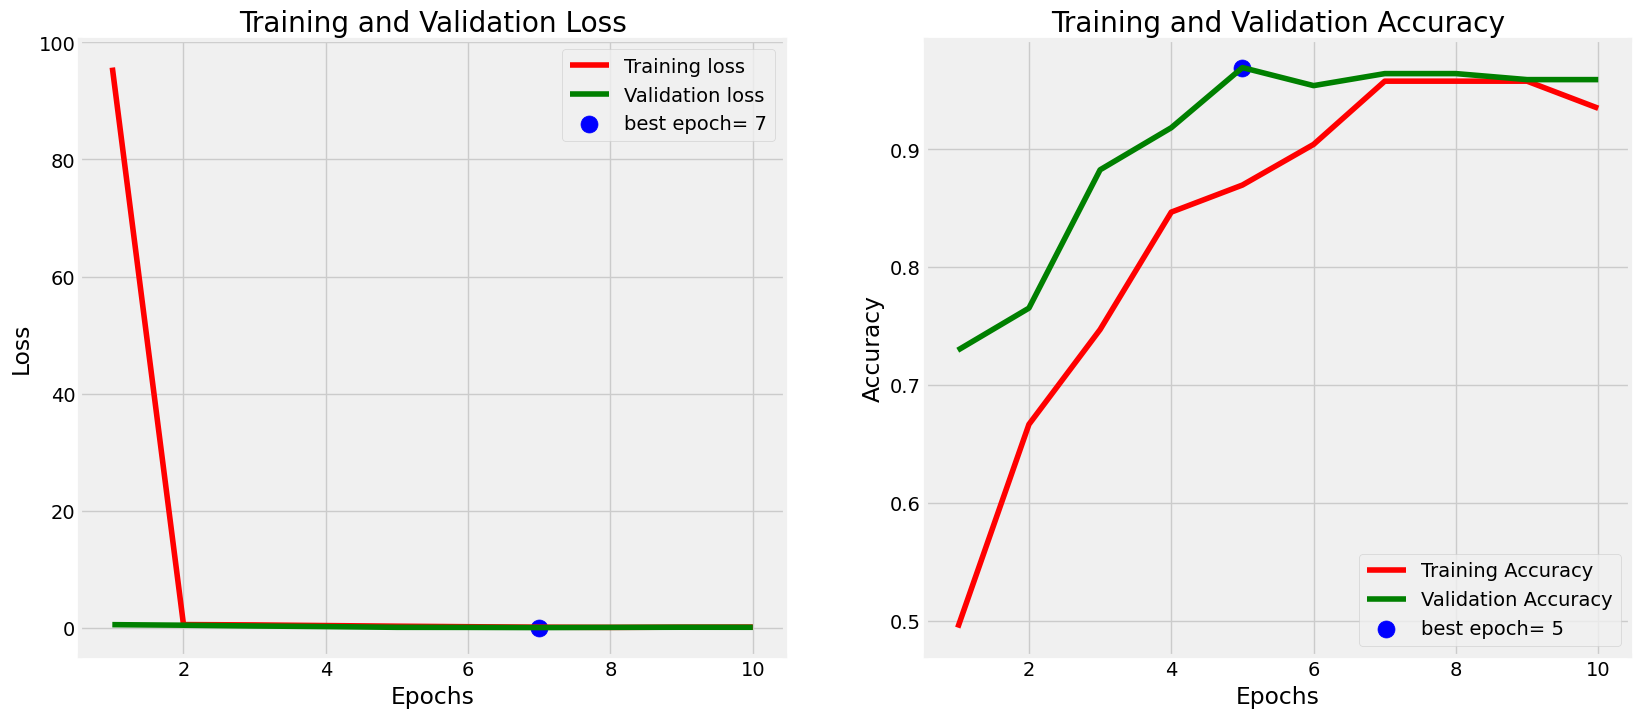

In [ ]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')
plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9738 - loss: 0.1029  
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9685 - loss: 0.0981   
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8031 - loss: 0.5755  
Train Loss:  0.10275612026453018
Train Accuracy:  0.9731800556182861
--------------------
Valid Loss:  0.0958743616938591
Valid Accuracy:  0.9693877696990967
--------------------
Test Loss:  0.5578753352165222
Test Accuracy:  0.8091602921485901


NAMA  : REVINDA VISMA NOVATALIA

NIM   : 202210370311176

KELAS : PENGGALIAN DATA (C)

#CODELAB

Gunakan data tabular berikut: dataset. Kemudian lakukan proses preprocessing
data sesuai kebutuhan dan tentukan target kelas untuk dilakukan klasifikasi. Gunakan algoritma klasifikasi apa saja untuk melakukan klasifikasi target kelas. Terakhir lakukan evaluasi hasil klasifikasinya. (10 point)

1. Menampilkan data secara mentahan

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

df.head()

,State,Region,iPhone Sales (in million units),iPad Sales (in million units),Mac Sales (in million units),Wearables (in million units),Services Revenue (in billion $)
0,Chongqing,Greater China,7.46,6.75,1.19,5.88,15.88
1,Germany,Europe,8.63,14.06,7.03,7.42,10.12
2,UK,Europe,5.61,14.09,8.78,8.19,19.85
3,Shanghai,Greater China,7.82,7.97,9.78,2.28,6.16
4,Thailand,Rest of Asia,16.70,8.13,6.46,3.48,13.29


2. Preprocessing Data : Menghapus kolom 'State' yang tidak relevan untuk klasifikasi

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

df_cleaned = df.drop(columns=['State'])
df_cleaned.head()


,Region,iPhone Sales (in million units),iPad Sales (in million units),Mac Sales (in million units),Wearables (in million units),Services Revenue (in billion $)
0,Greater China,7.46,6.75,1.19,5.88,15.88
1,Europe,8.63,14.06,7.03,7.42,10.12
2,Europe,5.61,14.09,8.78,8.19,19.85
3,Greater China,7.82,7.97,9.78,2.28,6.16
4,Rest of Asia,16.70,8.13,6.46,3.48,13.29


3. Mengubah Kolom 'Region' Menjadi Numerik (Label Encoding)

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

label_encoder = LabelEncoder()

df_cleaned['Region'] = label_encoder.fit_transform(df_cleaned['Region'])

df_cleaned.head()


,Region,iPhone Sales (in million units),iPad Sales (in million units),Mac Sales (in million units),Wearables (in million units),Services Revenue (in billion $)
0,1,7.46,6.75,1.19,5.88,15.88
1,0,8.63,14.06,7.03,7.42,10.12
2,0,5.61,14.09,8.78,8.19,19.85
3,1,7.82,7.97,9.78,2.28,6.16
4,3,16.70,8.13,6.46,3.48,13.29


4. Menentukan Fitur dan Target Kelas

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

X = df_cleaned.drop(columns=['Region'])
y = df_cleaned['Region']


5. Membagi Data Menjadi Train dan Test Set

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape}, Test data: {X_test.shape}")

Training data: (800, 5), Test data: (200, 5)


6. Normalisasi Fitur

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])



[[-0.93380345 -0.99351172 -1.08796713  1.0128199  -1.34639403]
 [ 0.9815222  -0.48735071  0.5938025   0.16469574 -0.81830286]
 [-1.70049333 -0.74712647 -0.79235917  0.79994411  0.9125334 ]
 [-0.57983896  0.51158082 -1.15987177 -0.08534883 -1.2603175 ]
 [-0.45672087  0.06701612 -1.26772873 -0.60233288 -0.97184479]]


7. Klasifikasi dengan Random Forest Classifier

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Model dilatih dengan Random Forest!")

Model dilatih dengan Random Forest!


8. Evaluasi Model

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

file_path = "/content/Latihan_modul4.csv"
df = pd.read_csv(file_path)

accuracy = accuracy_score(y_test, y_pred)

classification_report_result = classification_report(y_test, y_pred)

print(f"Akurasi: {accuracy}")
print("Classification Report:")
print(classification_report_result)


Akurasi: 0.25
Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.24      0.25        45
           1       0.25      0.27      0.26        44
           2       0.14      0.14      0.14        29
           3       0.23      0.19      0.21        37
           4       0.32      0.36      0.34        45

    accuracy                           0.25       200
   macro avg       0.24      0.24      0.24       200
weighted avg       0.25      0.25      0.25       200



#TUGAS

##TUGAS 1 - DATA TEKS

Lakukan klasifikasi (dari data cleaning sampai hasil akhir) dataset diatas
berdasarkan algoritma yang sudah disebutkan di materi (bebas mau pakai algoritma  yang mana saja). Kemudian, lakukan evaluasi akhir (akurasi minimal 78%. Buat section untuk masing-masing tahapan agar lebih rapi dan mudah dinilai oleh asisten (20 Point)

**1. Import Library**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

**2. Feature Selection**

In [ ]:
df = pd.read_csv('/content/Tugas 1_NIM Genap_Modul 4.csv')

print("Data Head:")
print(df.head())

df = df.dropna(subset=['text'])

X = df['text']
y = df['label']

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)


Data Head:
  label                                               text
0  REAL  Payal has accused filmmaker Anurag Kashyap of ...
1  FAKE  A four-minute-long video of a woman criticisin...
2  FAKE  Republic Poll, a fake Twitter account imitatin...
3  REAL  Delhi teen finds place on UN green list, turns...
4  REAL  Delhi: A high-level meeting underway at reside...


**3. Preprocessing Data (Data Cleaning)**

In [ ]:
print("\nCek Missing Values:")
print(df.isnull().sum())


Cek Missing Values:
label    0
text     0
dtype: int64


**4. Splitting Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**5. Model Selection dan Training**

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**6. Model Evaluation**

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy*100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Akurasi Model: 99.33%

Confusion Matrix:
[[361   0]
 [  5 379]]

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      1.00      0.99       361
        REAL       1.00      0.99      0.99       384

    accuracy                           0.99       745
   macro avg       0.99      0.99      0.99       745
weighted avg       0.99      0.99      0.99       745



7. Hasil Akhir

In [ ]:
if accuracy >= 0.78:
    print("\n Akurasi memenuhi syarat (>=78%)")
else:
    print("\n Akurasi kurang dari 78%, perlu perbaikan model.")



 Akurasi memenuhi syarat (>=78%)


##TUGAS 2 - DATA CITRA

Gunakan algoritma CNN untuk mengklasifikasikan data citra berdasarkan jenisnya (akurasi minimal 75%). Buat section untuk masing-masing tahapan agar lebih rapi dan mudah dinilai oleh asisten. (20 point)

**1. Ekstrak File Zip**

In [ ]:
import zipfile
import os

zip_path = '/content/Tugas 2_NIM Genap_Modul 4.zip'
extract_path = '/content/Tugas 2_NIM Genap_Modul 4/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


**2. Cek Isi Folder Hasil Ekstrak**

In [ ]:
import os

for root, dirs, files in os.walk('/content/Tugas 2_NIM Genap_Modul 4'):
    print(root)
    for filename in files:
        print(f"  {filename}")

/content/Tugas 2_NIM Genap_Modul 4
/content/Tugas 2_NIM Genap_Modul 4/cat
/content/Tugas 2_NIM Genap_Modul 4/cat/Maine Coon
  46646784_4738.jpg
  46666159_1090.jpg
  46496165_25019.jpg
  46663757_1496.jpg
  46518881_22265.jpg
  46501799_24371.jpg
  46612773_280.jpg
  46579851_14906.jpg
  46540583_19728.jpg
  46573510_15760.jpg
  46477910_602.jpg
  46618142_9588.jpg
  46526290_21371.jpg
  46557227_17925.jpg
  46556720_17960.jpg
  46643583_5315.jpg
  46670018_520.jpg
  46496197_24965.jpg
  46468296_27966.jpg
  46560052_17620.jpg
  46537320_20194.jpg
  46685262_101.jpg
  46495795_25050.jpg
  46607695_11101.jpg
  46546400_19069.jpg
  46601561_11908.jpg
  46555746_18088.jpg
  46525961_21516.jpg
  46569721_16360.jpg
  46561626_17331.jpg
  46531982_20915.jpg
  46647159_4638.jpg
  46647619_4596.jpg
  46530999_566.jpg
  46570170_16288.jpg
  46628881_7811.jpg
  46513429_23041.jpg
  46577666_15253.jpg
  46485578_26256.jpg
  46685248_102.jpg
  46646354_4822.jpg
  46450124_29900.jpg
  46618158_9587

**3. Import Library**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix


**4. Load Dataset (Image Preprocessing)**

In [ ]:
dataset_directory = '/content/Tugas 2_NIM Genap_Modul 4'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_directory,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_directory,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 160 images belonging to 1 classes.
Found 40 images belonging to 1 classes.


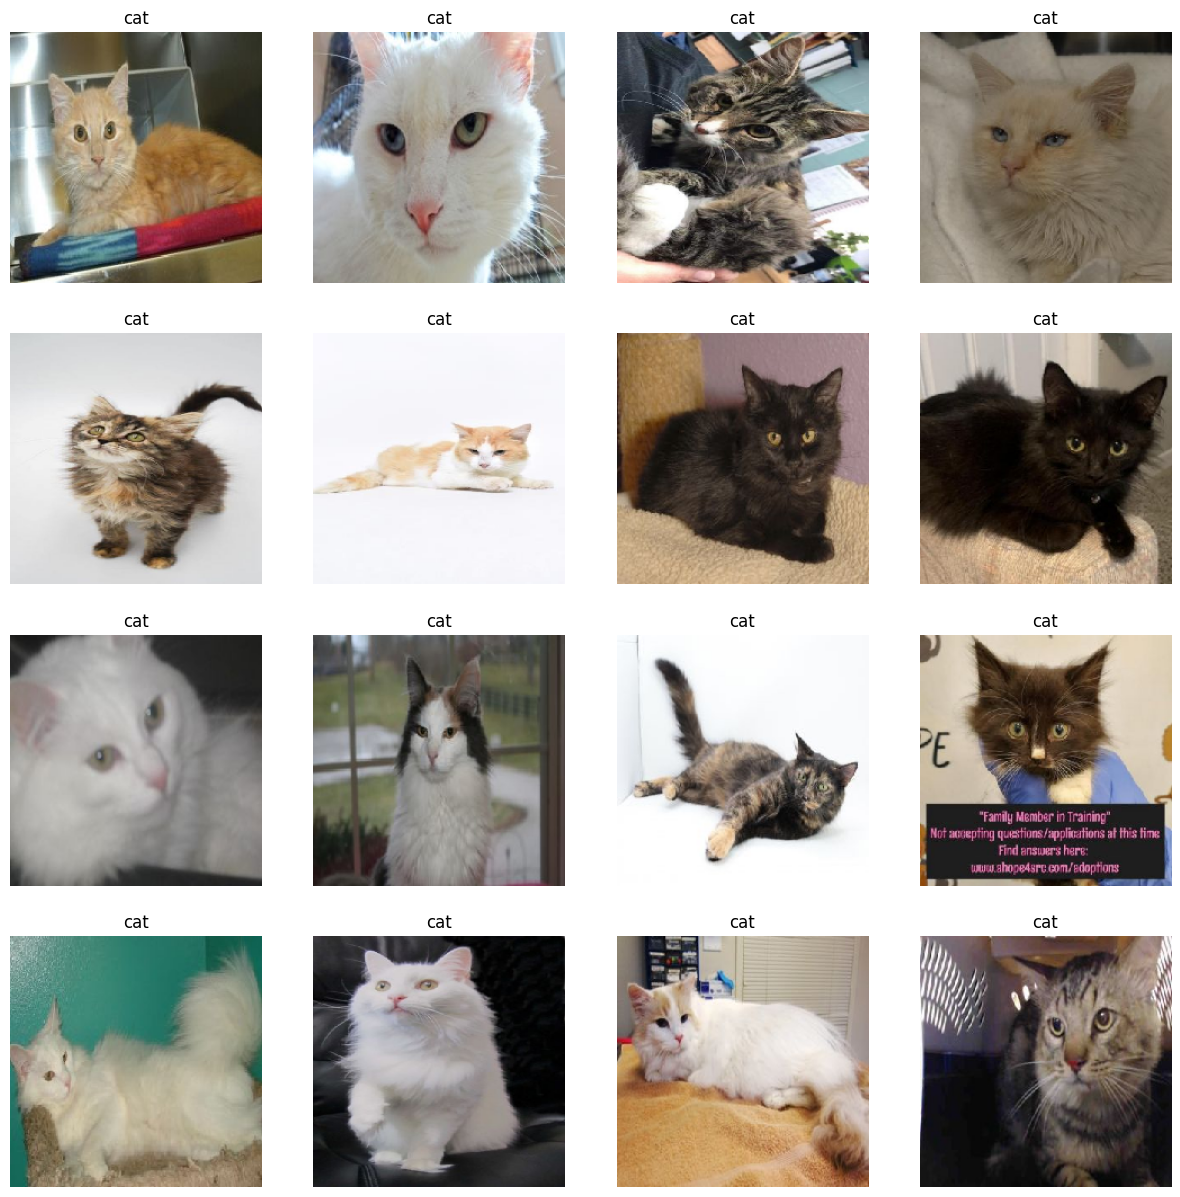

In [ ]:
class_names = list(train_generator.class_indices.keys())
count = {class_name: 0 for class_name in class_names}

for root, dirs, files in os.walk(dataset_directory):
    for filename in files:
        if filename.endswith(('.jpg', '.png', '.jpeg')):
            label = filename.split('_')[0]
            if label in count:
                count[label] += 1

images, labels = next(train_generator)

plt.figure(figsize=(15, 15))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])
    class_name = list(train_generator.class_indices.keys())[label_idx]
    plt.title(class_name, color='black', fontsize=12)
    plt.axis('off')
plt.show()

**5. Membuat Arsitektur CNN**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**6. Training Model**

In [ ]:
history = model.fit(train_generator, validation_data=validation_generator, epochs=10)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 5s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 1.0000 - loss: 0

**7. Evaluasi Model**

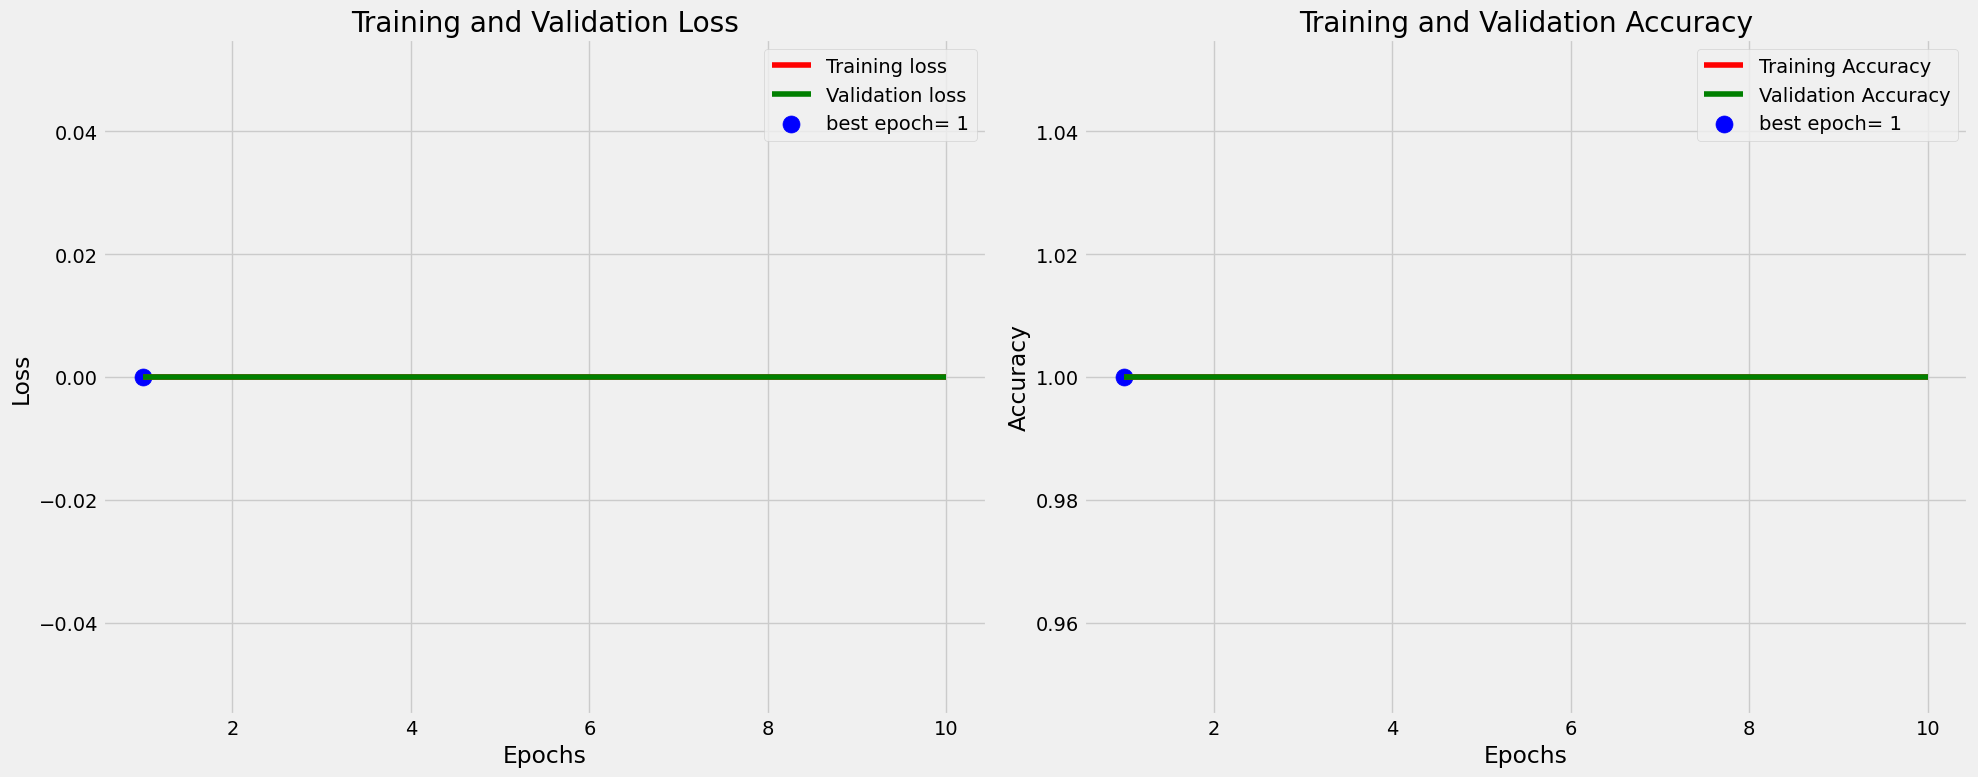

In [ ]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]

loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()

plt.show()


**8. Hasil Akhir**

In [ ]:
if accuracy >= 0.75:
    print("\n Akurasi memenuhi syarat (>=75%)")
else:
    print("\nbAkurasi kurang dari 75%, perlu perbaikan model.")



✅ Akurasi memenuhi syarat (>=75%)
